# Curvas de loss del VAE (reconstrucción, KL, total)

Lee un `vae_metrics{N}.csv` (el que escribe `Logger.log_scalars` en `VAE.py` /
`modelo_semisup.py`, una fila por época) y grafica train vs val para las tres
componentes de la pérdida: reconstrucción, KL y total.

Ajusta `CSV_PATH` a la corrida que quieras revisar (por defecto la de
`data_vae/vae2/vae_metrics2.csv`).

**Corre este notebook con un kernel de Python LOCAL** (no el runtime de Colab): `data_vae/` es una carpeta local, no está en git ni se clona en Colab.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Sube desde `start` hasta encontrar la raiz del repo (marcada por .git).

    Evita depender de dónde este el directorio de trabajo del kernel; solo
    funciona con un kernel LOCAL (no el runtime remoto de Colab, que clona el
    repo pero no tiene `data_vae/` -- esa carpeta es local, no esta en git).
    """
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
    raise FileNotFoundError(
        f"no se encontro la raiz del repo (.git) subiendo desde {start}; "
        "corre este notebook con un kernel de Python LOCAL, no con Colab.")


REPO = find_repo_root(Path.cwd())
CSV_PATH = REPO / "data_vae" / "vae2" / "vae_metrics2.csv"

df = pd.read_csv(CSV_PATH)
print(f"{CSV_PATH}  ->  {len(df)} épocas")
df.head()


/home/tamara/AS4501-Proyect/data_vae/vae2/vae_metrics2.csv  ->  100 épocas


,epoch,loss/total_train,loss/recon_train,loss/kl_train,loss/total_val,loss/recon_val,loss/kl_val,val/mse_px,val/ssim,val/psnr,val/active_dims,val/kl_per_dim_mean,beta,lr
0,1,7.966951e+02,791.731701,1.489020e+02,430.409197,367.852787,62.556412,0.020436,NaN,NaN,64,0.977444,0.033333,0.001
1,2,2.340582e+09,392.635368,3.510872e+10,595.988181,551.128254,44.859923,0.030618,NaN,NaN,64,0.700936,0.066667,0.001
2,3,3.734412e+02,368.393984,5.047234e+01,395.418511,336.241622,59.176891,0.018680,NaN,NaN,64,0.924639,0.100000,0.001
3,4,3.538025e+02,346.034111,5.826307e+01,383.165796,322.730088,60.435712,0.017929,NaN,NaN,64,0.944308,0.133333,0.001
4,5,3.414240e+02,331.089632,6.200623e+01,373.627650,298.414175,75.213480,0.016579,NaN,NaN,64,1.175211,0.166667,0.001


## Curvas train vs val

Una fila de 3 subplots: total, reconstrucción y KL. El eje Y usa escala log
cuando hay picos de inestabilidad numérica (frecuentes en las primeras épocas
antes de que el warm-up de beta estabilice el entrenamiento) que aplastarían
el resto de la curva en escala lineal.

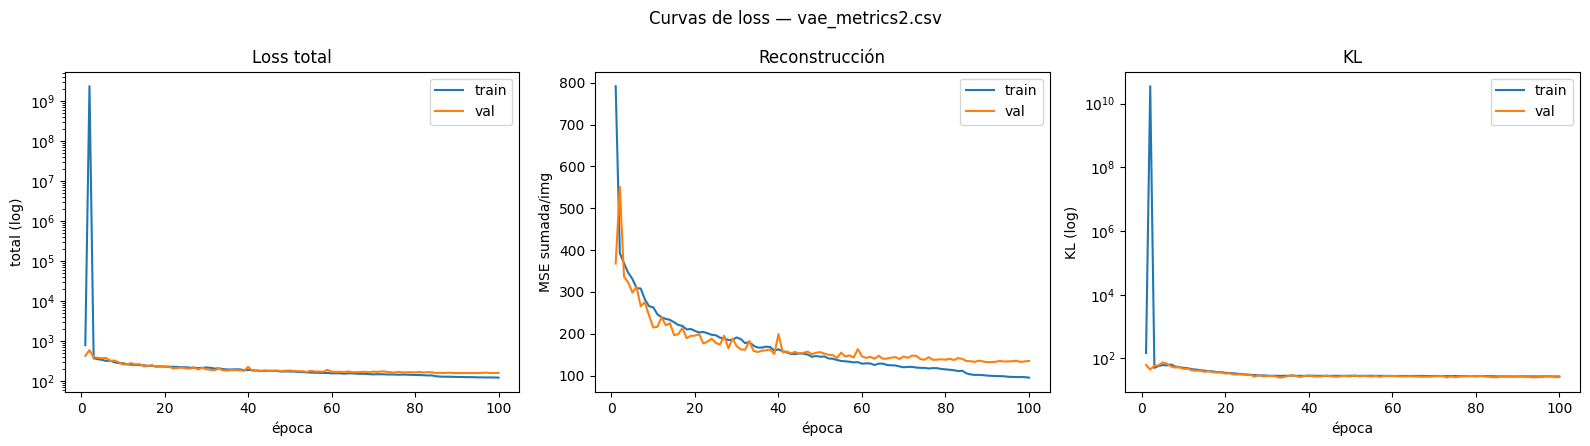

In [2]:
def plot_train_val(ax, epochs, train, val, title, ylabel, logy=False):
    ax.plot(epochs, train, label="train")
    ax.plot(epochs, val, label="val")
    ax.set_xlabel("época")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if logy:
        ax.set_yscale("log")
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plot_train_val(axes[0], df["epoch"], df["loss/total_train"], df["loss/total_val"],
               "Loss total", "total (log)", logy=True)
plot_train_val(axes[1], df["epoch"], df["loss/recon_train"], df["loss/recon_val"],
               "Reconstrucción", "MSE sumada/img")
plot_train_val(axes[2], df["epoch"], df["loss/kl_train"], df["loss/kl_val"],
               "KL", "KL (log)", logy=True)

fig.suptitle(f"Curvas de loss — {CSV_PATH.name}")
plt.tight_layout()
plt.show()


## Mismas curvas, sin picos de inestabilidad

Si alguna época tuvo un pico numérico (loss varios órdenes de magnitud por
encima del resto), esta celda lo recorta usando el percentil 99 de cada serie
para ver el detalle de la convergencia normal en escala lineal.

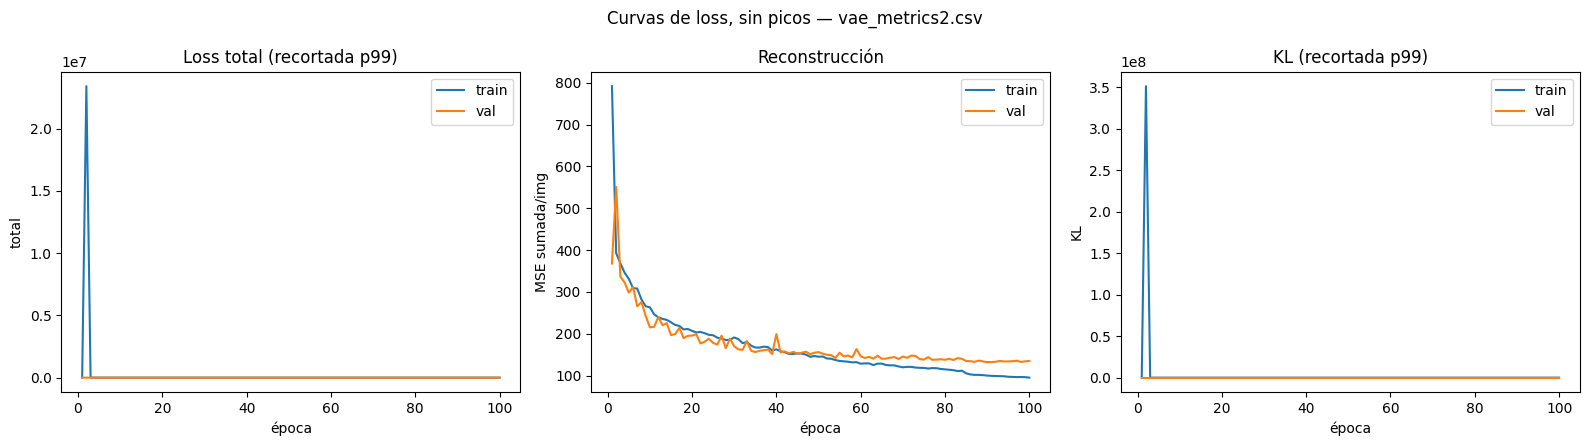

In [3]:
def clip_to_p99(s):
    cap = s.quantile(0.99)
    return s.clip(upper=cap)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plot_train_val(axes[0], df["epoch"], clip_to_p99(df["loss/total_train"]),
               clip_to_p99(df["loss/total_val"]), "Loss total (recortada p99)", "total")
plot_train_val(axes[1], df["epoch"], df["loss/recon_train"], df["loss/recon_val"],
               "Reconstrucción", "MSE sumada/img")
plot_train_val(axes[2], df["epoch"], clip_to_p99(df["loss/kl_train"]),
               clip_to_p99(df["loss/kl_val"]), "KL (recortada p99)", "KL")

fig.suptitle(f"Curvas de loss, sin picos — {CSV_PATH.name}")
plt.tight_layout()
plt.show()
